In [2]:
# %pip install pandas
# %pip install yfinance

%pip install zoneinfo


Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement zoneinfo (from versions: none)
ERROR: No matching distribution found for zoneinfo
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


Set-up and import

In [3]:

import sys
sys.path.append("../src")
import pandas as pd
import matplotlib.pyplot as plt
from black_scholes import black_scholes_price
from data_loader import (get_expiries, build_options_dataframe, get_underlying_history,
    compute_log_returns,
    compute_rolling_hist_vol)


This is where we can change the ticker and eventually adjust the risk free rate

In [48]:
ticker = "AAPL"
expiry = get_expiries(ticker)[0]
r = 0.04

Pull data

In [49]:
options_df = build_options_dataframe(ticker, expiry)
options_df.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,mid,option_type,S,expiry,T
0,AAPL260316C00215000,2026-03-13 18:48:03+00:00,215.0,36.72,33.95,36.45,-10.449997,-22.153906,57.0,59.0,0.761721,True,REGULAR,USD,35.200,call,250.119995,2026-03-16,0.00693
1,AAPL260316C00220000,2026-03-11 19:27:08+00:00,220.0,40.33,28.20,31.90,0.000000,0.000000,1.0,21.0,1.265629,True,REGULAR,USD,30.050,call,250.119995,2026-03-16,0.00693
2,AAPL260316C00222500,2026-03-06 15:17:02+00:00,222.5,34.26,25.70,29.40,0.000000,0.000000,152.0,11.0,1.186039,True,REGULAR,USD,27.550,call,250.119995,2026-03-16,0.00693
3,AAPL260316C00225000,2026-03-10 17:28:01+00:00,225.0,37.32,23.25,26.40,0.000000,0.000000,3.0,17.0,0.998047,True,REGULAR,USD,24.825,call,250.119995,2026-03-16,0.00693
4,AAPL260316C00227500,2026-03-12 19:55:41+00:00,227.5,28.40,21.05,24.55,0.000000,0.000000,6.0,10.0,0.581059,True,REGULAR,USD,22.800,call,250.119995,2026-03-16,0.00693


Add to black scholes

In [50]:
options_df["K"] = options_df["strike"]
options_df["sigma"] = options_df["impliedVolatility"]
options_df["r"] = r

options_df = options_df[
    (options_df["K"] > 0) &
    (options_df["T"] > 0) &
    (options_df["sigma"] > 0) &
    (options_df["mid"] > 0)
].copy()


options_df.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,...,contractSize,currency,mid,option_type,S,expiry,T,K,sigma,r
0,AAPL260316C00215000,2026-03-13 18:48:03+00:00,215.0,36.72,33.95,36.45,-10.449997,-22.153906,57.0,59.0,...,REGULAR,USD,35.200,call,250.119995,2026-03-16,0.00693,215.0,0.761721,0.04
1,AAPL260316C00220000,2026-03-11 19:27:08+00:00,220.0,40.33,28.20,31.90,0.000000,0.000000,1.0,21.0,...,REGULAR,USD,30.050,call,250.119995,2026-03-16,0.00693,220.0,1.265629,0.04
2,AAPL260316C00222500,2026-03-06 15:17:02+00:00,222.5,34.26,25.70,29.40,0.000000,0.000000,152.0,11.0,...,REGULAR,USD,27.550,call,250.119995,2026-03-16,0.00693,222.5,1.186039,0.04
3,AAPL260316C00225000,2026-03-10 17:28:01+00:00,225.0,37.32,23.25,26.40,0.000000,0.000000,3.0,17.0,...,REGULAR,USD,24.825,call,250.119995,2026-03-16,0.00693,225.0,0.998047,0.04
4,AAPL260316C00227500,2026-03-12 19:55:41+00:00,227.5,28.40,21.05,24.55,0.000000,0.000000,6.0,10.0,...,REGULAR,USD,22.800,call,250.119995,2026-03-16,0.00693,227.5,0.581059,0.04


In [51]:
print(black_scholes_price)
print(type(black_scholes_price))
print("options_df shape:", options_df.shape)

if len(options_df) == 0:
    print("options_df is empty")
else:
    test_row = options_df.iloc[0]

    test_result = black_scholes_price(
        S=test_row["S"],
        K=test_row["K"],
        T=test_row["T"],
        r=test_row["r"],
        sigma=test_row["impliedVolatility"],
        option_type=test_row["option_type"]
    )

    print("RESULT:", test_result)
    print("TYPE:", type(test_result))

<function black_scholes_price at 0x1103feb80>
<class 'function'>
options_df shape: (58, 22)
RESULT: 33.249877269771815
TYPE: <class 'numpy.float64'>


Run BS pricing model 

In [52]:
options_df["bs_price_imp_vol"] = options_df.apply(
    lambda row: black_scholes_price(
        S=row["S"],
        K=row["K"],
        T=row["T"],
        r=row["r"],
        sigma=row["impliedVolatility"],
        option_type=row["option_type"]
    ),
    axis=1
)

options_df["mispricing_imp_vol"] = options_df["mid"] - options_df["bs_price_imp_vol"]
options_df["abs_error_imp_vol"] = options_df["mispricing_imp_vol"].abs()

Quick peek at output 

In [53]:
view_cols = [
    "contractSymbol", "option_type", "K", "mid", "bs_price_imp_vol",
    "mispricing_imp_vol", "abs_error_imp_vol", "sigma", "volume", "openInterest"
]

options_df.sort_values("abs_error_imp_vol", ascending=False)[view_cols].head(20)

,contractSymbol,option_type,K,mid,bs_price_imp_vol,mispricing_imp_vol,abs_error_imp_vol,sigma,volume,openInterest
48,AAPL260316P00252500,put,252.5,3.450,82.042407,-78.592407,78.592407,0.243172,4618.0,527.0
12,AAPL260316C00247500,call,247.5,3.725,-72.957438,76.682438,76.682438,0.256355,674.0,152.0
46,AAPL260316P00247500,put,247.5,1.160,-74.806382,75.966382,75.966382,0.251472,5100.0,2142.0
14,AAPL260316C00252500,call,252.5,1.035,76.586845,-75.551845,75.551845,0.224861,9334.0,305.0
47,AAPL260316P00250000,put,250.0,2.075,-55.582393,57.657393,57.657393,0.242195,5688.0,1371.0
13,AAPL260316C00250000,call,250.0,2.170,-54.975414,57.145414,57.145414,0.239876,6720.0,166.0
49,AAPL260316P00255000,put,255.0,5.350,57.257715,-51.907715,51.907715,0.279304,2778.0,800.0
11,AAPL260316C00245000,call,245.0,5.375,-41.544690,46.919690,46.919690,0.286872,340.0,108.0
10,AAPL260316C00242500,call,242.5,7.750,-34.895058,42.645058,42.645058,0.400397,94.0,40.0
45,AAPL260316P00245000,put,245.0,0.600,-41.676579,42.276579,42.276579,0.263191,2580.0,496.0


Plotting (what does this mean, what am I looking at, what does this tell me? Who knows... hopefully the PhD research quants)

In [54]:
calls = options_df[options_df["option_type"] == "call"]
puts = options_df[options_df["option_type"] == "put"]

plt.figure(figsize=(10,6))

plt.scatter(calls["K"], calls["mispricing"], label="Calls")
plt.scatter(puts["K"], puts["mispricing"], label="Puts")

plt.axhline(0)
plt.xlabel("Strike")
plt.ylabel("Market - BS")
plt.legend()
plt.title("Mispricing by option type")
plt.show()

KeyError: 'mispricing'

<Figure size 1000x600 with 0 Axes>

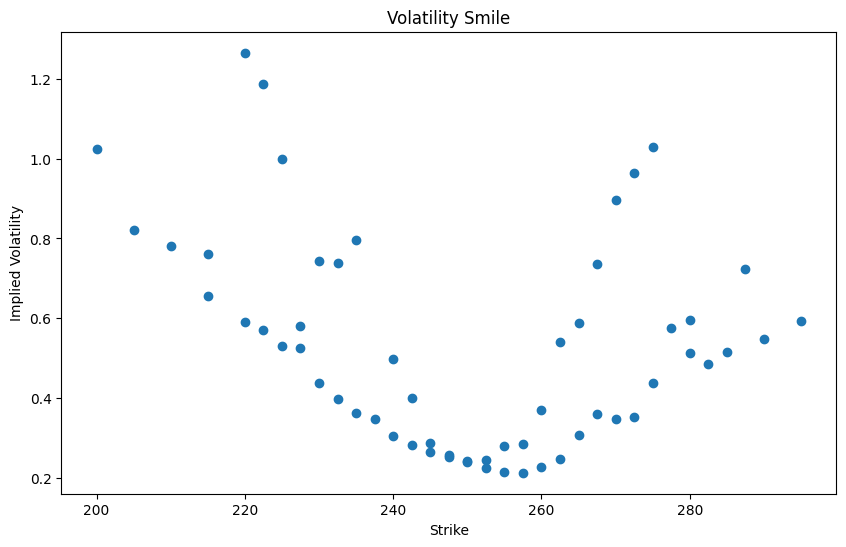

In [55]:
#implied vol vs strike 
plt.figure(figsize=(10,6))

plt.scatter(options_df["K"], options_df["sigma"])

plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("Volatility Smile")
plt.show()


In [56]:
hist = get_underlying_history(ticker, period="1y")
hist.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-03-14 00:00:00-04:00,210.333268,213.021548,208.670517,212.563553,60107600,0.0,0.0
2025-03-17 00:00:00-04:00,212.384357,214.286072,209.058854,213.071365,48073400,0.0,0.0
2025-03-18 00:00:00-04:00,213.230666,214.216361,210.572254,211.767044,42432400,0.0,0.0
2025-03-19 00:00:00-04:00,213.290391,217.810683,212.822430,214.305969,54385400,0.0,0.0
2025-03-20 00:00:00-04:00,213.061390,216.546202,211.299067,213.170914,48862900,0.0,0.0


In [57]:
hist[["Close"]].tail()


,Close
Date,
2026-03-09 00:00:00-04:00,259.880005
2026-03-10 00:00:00-04:00,260.829987
2026-03-11 00:00:00-04:00,260.809998
2026-03-12 00:00:00-04:00,255.759995
2026-03-13 00:00:00-04:00,250.119995


In [58]:
## Computing log returns of close 
hist["log_return"] = compute_log_returns(hist["Close"])
hist[["Close", "log_return"]].tail(10)

,Close,log_return
Date,,
2026-03-02 00:00:00-05:00,264.720001,0.002042
2026-03-03 00:00:00-05:00,263.750000,-0.003671
2026-03-04 00:00:00-05:00,262.519989,-0.004674
2026-03-05 00:00:00-05:00,260.290009,-0.008531
2026-03-06 00:00:00-05:00,257.459991,-0.010932
2026-03-09 00:00:00-04:00,259.880005,0.009356
2026-03-10 00:00:00-04:00,260.829987,0.003649
2026-03-11 00:00:00-04:00,260.809998,-0.000077
2026-03-12 00:00:00-04:00,255.759995,-0.019553


In [59]:
## Compute 30 day rolling historical volatility
hist["hist_vol_30d"] = compute_rolling_hist_vol(hist["Close"], window=30)
hist[["Close", "log_return", "hist_vol_30d"]].tail(15)

,Close,log_return,hist_vol_30d
Date,,,
2026-02-23 00:00:00-05:00,266.179993,0.006029,0.289554
2026-02-24 00:00:00-05:00,272.140015,0.022144,0.296010
2026-02-25 00:00:00-05:00,274.230011,0.007651,0.296487
2026-02-26 00:00:00-05:00,272.950012,-0.004679,0.297043
2026-02-27 00:00:00-05:00,264.179993,-0.032658,0.312836
2026-03-02 00:00:00-05:00,264.720001,0.002042,0.312085
2026-03-03 00:00:00-05:00,263.750000,-0.003671,0.310570
2026-03-04 00:00:00-05:00,262.519989,-0.004674,0.291637
2026-03-05 00:00:00-05:00,260.290009,-0.008531,0.293196


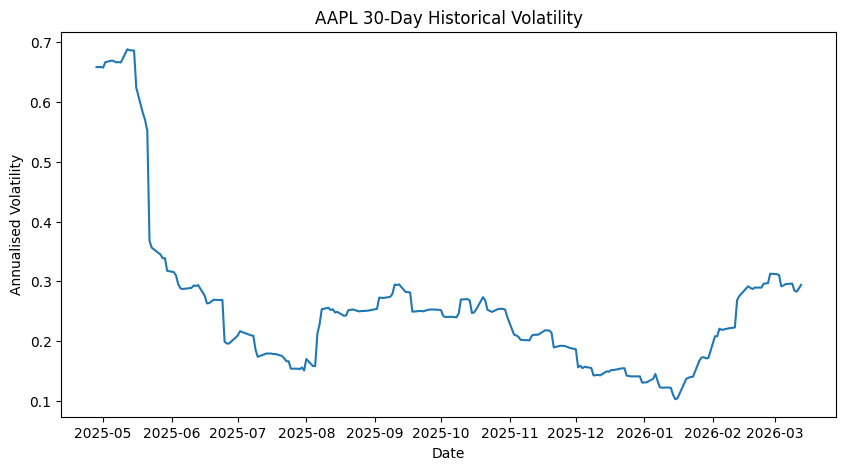

In [60]:
## Visualise last 6 months

plt.figure(figsize=(10, 5))
plt.plot(hist.index, hist["hist_vol_30d"])
plt.xlabel("Date")
plt.ylabel("Annualised Volatility")
plt.title(f"{ticker} 30-Day Historical Volatility")
plt.show()

In [61]:
## Compute single BS sigma implied vol for a given option
latest_hist_vol = hist["hist_vol_30d"].dropna().iloc[-1]
print("Latest 30D historical volatility:", latest_hist_vol)

Latest 30D historical volatility: 0.29409459143839867


In [62]:
##Adding historical volatility to our options dataframe 
options_df["sigma_hist"] = latest_hist_vol

In [63]:
options_df["bs_price_hist"] = options_df.apply(
    lambda row: black_scholes_price(
        S=row["S"],
        K=row["K"],
        T=row["T"],
        r=row["r"],
        sigma=row["sigma_hist"],
        option_type=row["option_type"]
    ),
    axis=1
)

In [64]:
##These numbers are sus no? 

options_df[["bs_price_hist"]].head()

,bs_price_hist
0,35.179586
1,30.180955
2,27.681470
3,25.180629
4,22.670785


In [65]:
options_df["mispricing_imp_vol"] = options_df["mid"] - options_df["bs_price_imp_vol"]
options_df["abs_error_imp_vol"] = options_df["mispricing_imp_vol"].abs()

options_df["mispricing_hist"] = options_df["mid"] - options_df["bs_price_hist"]
options_df["abs_error_hist"] = options_df["mispricing_hist"].abs()

print("Mean abs error using implied vol:   ", options_df["abs_error_imp_vol"].mean())
print("Mean abs error using historical vol:", options_df["abs_error_hist"].mean())

Mean abs error using implied vol:    21.242203643983856
Mean abs error using historical vol: 14.952402631106432


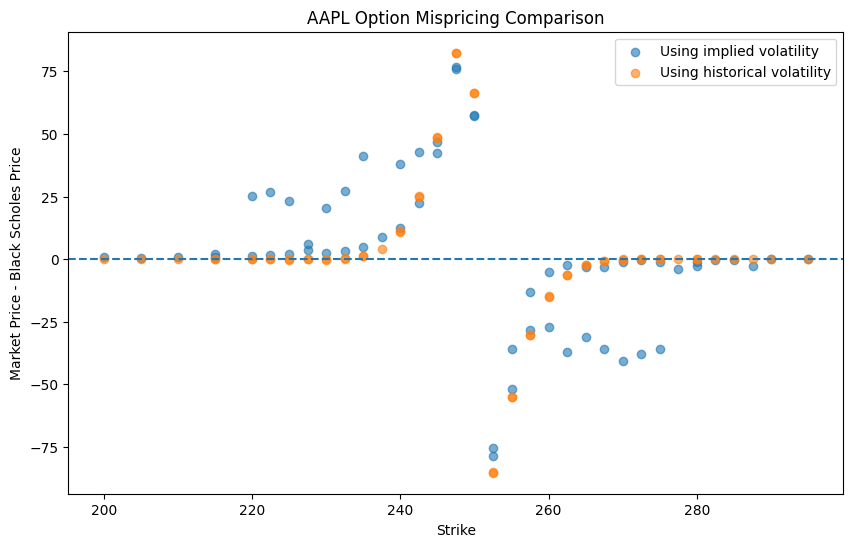

In [66]:
##Option mispricing comparison plot

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    options_df["K"],
    options_df["mispricing_imp_vol"],
    alpha=0.6,
    label="Using implied volatility"
)

plt.scatter(
    options_df["K"],
    options_df["mispricing_hist"],
    alpha=0.6,
    label="Using historical volatility"
)

plt.axhline(0, linestyle="--")
plt.xlabel("Strike")
plt.ylabel("Market Price - Black Scholes Price")
plt.title(f"{ticker} Option Mispricing Comparison")
plt.legend()

plt.show()

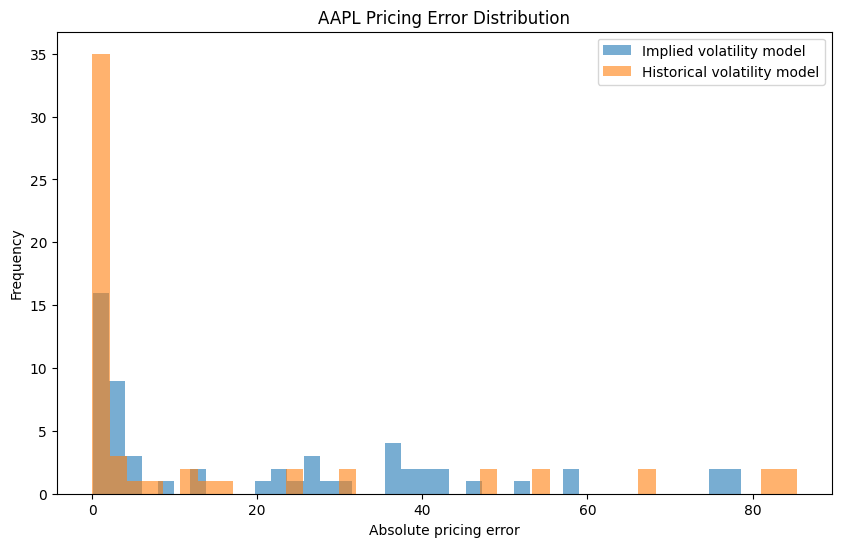

In [67]:
##Error distribution plot 
plt.figure(figsize=(10,6))

plt.hist(
    options_df["abs_error_imp_vol"],
    bins=40,
    alpha=0.6,
    label="Implied volatility model"
)

plt.hist(
    options_df["abs_error_hist"],
    bins=40,
    alpha=0.6,
    label="Historical volatility model"
)

plt.xlabel("Absolute pricing error")
plt.ylabel("Frequency")
plt.title(f"{ticker} Pricing Error Distribution")
plt.legend()

plt.show()